Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 196ms/step - loss: 0.1483 - val_loss: 0.1050
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 90s 193ms/step - loss: 0.1043 - val_loss: 0.1018
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 91s 193ms/step - loss: 0.1012 - val_loss: 0.0991
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 90s 191ms/step - loss: 0.0992 - val_loss: 0.0976
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 192ms/step - loss: 0.0979 - val_loss: 0.0965
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


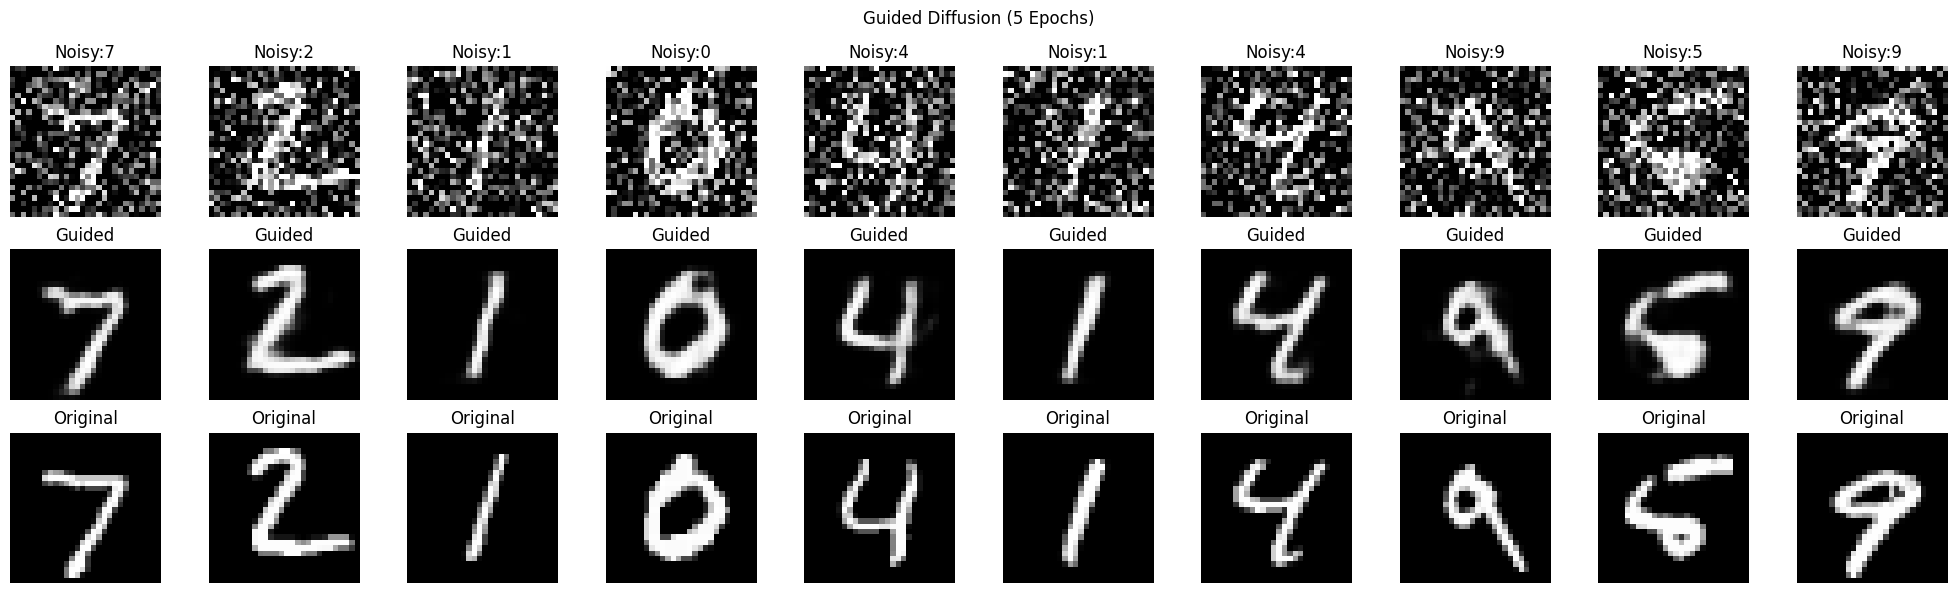

In [4]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Load MNIST Dataset
# -----------------------------------
(x_train, y_train), (x_test, y_test) = \
    tf.keras.datasets.mnist.load_data()

# Normalize images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# -----------------------------------
# Add Noise (Forward Diffusion)
# -----------------------------------
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# -----------------------------------
# Label Embedding
# -----------------------------------
label_input = tf.keras.Input(shape=(1,))

embedding = layers.Embedding(
    input_dim=10,
    output_dim=28*28
)(label_input)

embedding = layers.Flatten()(embedding)

embedding = layers.Reshape((28,28,1))(embedding)

# -----------------------------------
# Image Input
# -----------------------------------
image_input = tf.keras.Input(shape=(28,28,1))

# Combine image and label
x = layers.Concatenate()([image_input, embedding])

# -----------------------------------
# CNN Denoising Model
# -----------------------------------
x = layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = layers.UpSampling2D((2,2))(x)

output = layers.Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

# -----------------------------------
# Build Model
# -----------------------------------
model = tf.keras.Model(
    inputs=[image_input, label_input],
    outputs=output
)

# -----------------------------------
# Compile Model
# -----------------------------------
model.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# -----------------------------------
# Train Model (5 Epochs)
# -----------------------------------
history = model.fit(
    [x_train_noisy, y_train],
    x_train,
    epochs=5,
    batch_size=128,
    validation_data=(
        [x_test_noisy, y_test],
        x_test
    )
)

# -----------------------------------
# Predict Denoised Images
# -----------------------------------
decoded_images = model.predict(
    [x_test_noisy[:10], y_test[:10]]
)

# -----------------------------------
# Visualization
# -----------------------------------
plt.figure(figsize=(20,6))

for i in range(10):

    # Noisy Image
    ax = plt.subplot(3,10,i+1)

    plt.imshow(
        x_test_noisy[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(f"Noisy:{y_test[i]}")
    plt.axis('off')

    # Guided Reconstruction
    ax = plt.subplot(3,10,i+11)

    plt.imshow(
        decoded_images[i].reshape(28,28),
        cmap='gray'
    )

    plt.title("Guided")
    plt.axis('off')

    # Original Image
    ax = plt.subplot(3,10,i+21)

    plt.imshow(
        x_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title("Original")
    plt.axis('off')

plt.suptitle("Guided Diffusion (5 Epochs)")

plt.tight_layout()

plt.show()